# Fit Parameters That aren't Wavelength-Dependent

The most universal case for this is fitting offset angles (due to misalignments). These aren't wavelength-dependent. If you are using any kind of physical model, such as the Joost 't Hart 2021 physical models, you will also fit like this. I am doing a combination in this tutorial: I am going to fit the Joost 't Hart 2021 HWP physical model and offset angles, but I'm going to use my wavelength-fit derotator retardances.

# Step 1: Define Custom Mueller Matrix Functions
If you are using the Joost 't Hart models, those already exist in `pyMuellerMat.commmon_mm_functions`, so you don't need to do this. More detailed explanation of these custom functions is in `system_mueller_matrix_tutorial.ipynb`. I am going to define a custom elliptical retarder function for the derotator using my fits from the previous step. I'm also going to create a custom function using the imperfect Wollaston fits.

In [1]:
from pyPolCal.csv_tools import model_data
from pyPolCal.mm_registry import register_mm_function
import numpy as np
from pyPolCal.constants import wavelength_bins
from pyMuellerMat.common_mm_functions import elliptical_retarder_function , wollaston_prism_function

# Retreiving fits
wavelength_fits_dir = 'wavelength_fit_results' # path to fitted p dicts
wavelength_fits_df = model_data(wavelength_fits_dir) # saving to DataFrame
derotator_phi_h = wavelength_fits_df['image_rotator_phi_h'].to_numpy() # linear h retardance
derotator_phi_45 = wavelength_fits_df['image_rotator_phi_45'].to_numpy() # linear 45 retardance
derotator_phi_r = wavelength_fits_df['image_rotator_phi_r'].to_numpy() # circular retardance
wollaston_eta = wavelength_fits_df['wollaston_eta'].to_numpy()

@register_mm_function()
def fitted_derotator_function_12_28_2025(wavelength=500): # Only keyword arguments!
    phi_h = derotator_phi_h
    phi_45 = derotator_phi_45
    phi_r = derotator_phi_r

    # Interpolating retardance as a function of wavelength 
    phi_h_interp = np.interp(wavelength, wavelength_bins, phi_h)
    phi_45_interp = np.interp(wavelength, wavelength_bins, phi_45)
    phi_r_interp = np.interp(wavelength, wavelength_bins, phi_r)

    # using pyMuellerMat's elliptical retarder function
    return elliptical_retarder_function(phi_h_interp, phi_45_interp, phi_r_interp)

@register_mm_function()
def fitted_wollaston_function_12_28_2025(beam='o',wavelength=500): # Only keyword arguments!
    eta = wollaston_eta

    # Interpolating retardance as a function of wavelength
    eta_interp = np.interp(wavelength, wavelength_bins, eta)

    # using pyMuellerMat's elliptical retarder function
    return wollaston_prism_function(beam=beam,eta=eta_interp)


Mueller matrix function 'fitted_derotator_function_12_28_2025' is already registered. Overwriting.
Mueller matrix function 'fitted_wollaston_function_12_28_2025' is already registered. Overwriting.


/home/thomasmc/miniconda3/envs/charisenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 2: Import Data and Modify CSV Reader if Necessary
Currently, the only way you can pass an argument to a component in the system dictionary is through configuration lists. This is how we pass the HWP and derotator angle. If you want to pass the wavelength to something new, you need to modify the `'wavelength'` mode in `read_csv()` in `csv_tools.py` that adds wavelength to the configuration list. It currently (12/2025) adds wavelength to the Wollaston, HWP, and derotator.

In [2]:
# EXAMPLE MODIFICATION (see line 341 of csv_tools.py)

        # if mode == 'wavelength': 
        #     wavelength = row["wavelength_bin"]
        #     # Building dictionary with wavelength
        #     row_data = {
        #         "hwp": {"theta": hwp_theta, "wavelength": wavelength},
        #         "image_rotator": {"theta": imr_theta, "wavelength": wavelength},
        #         "wollaston": {"wavelength":wavelength},
        #         "my_component" : {"wavelength":wavelength} CUSTOM COMPONENT HERE
        #     }

The function `read_csv_physical_model_all_bins()` will read all bins into one array. It calls `read_csv()` with `mode='wavelength'` so if you updated `read_csv()` correctly then you are set.

In [3]:
from pyPolCal.csv_tools import read_csv_physical_model_all_bins
from importlib.resources import files

# Defining Path to my CSVs

csvdir = files('pyPolCal.CHARIS.datacsvs').joinpath('nbs_in_internalcal_csvs')

# Reading in data
interleaved_values_all, interleaved_stds_all, configuration_list_all = read_csv_physical_model_all_bins(csvdir)

# Step 3: Generate System Mueller Matrix
Update your wavelength fits system dictionary.

In [4]:
from pyPolCal.utils import generate_system_mueller_matrix

system_dict = {
    "components" : {
        "wollaston" : {
        "type" : "fitted_wollaston_function_12_28_2025",
        "properties" : {"beam": 'o'}, 
        "tag": "internal",
        },

        "nbs_rot": {
            "type": "rotator_function",
            "properties": {"pa": 90},
            "tag": "internal",
        },
        "image_rotator" : {
        "type" : "fitted_derotator_function_12_28_2025",
        "properties" : {"delta_theta":0}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "two_layer_HWP_function", # Joost 't Hart 2021 HWP model
            "properties" : {"delta_theta": 0},
            "tag": "internal",
        },


        "lp" :{
            "type" : "diattenuator_retarder_function",
            "properties" : {"epsilon": 1, "delta_theta":0}, 
            "tag": "internal",
        },
}
}
system_mm = generate_system_mueller_matrix(system_dict)
system_mm.evaluate()

array([[0.00040678, 0.00040678, 0.        , 0.        ],
       [0.00040678, 0.00040678, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ]])

# Step 4: Define Starting Guesses and Bounds

This uses the exact same format as the previous tutorial notebook.

In [5]:
p0_dict = {
    'image_rotator': {'delta_theta':0},
    'hwp' : {'w_SiO2':1.623, 'w_MgF2':1.268,'delta_theta':0}, # starting guesses from Joost 't Hart 2021
    'lp' :{'delta_theta':0},
}
offset_bounds = (-5,5) # degrees
wsio2_bounds = (0.6*1.623, 1.623*1.4) 
wmgf2_bounds = (0.6*1.268, 1.268*1.4)
bounds = [offset_bounds, wsio2_bounds, wmgf2_bounds, offset_bounds, offset_bounds] # in order they appear in p0_dict

# Step 5: Minimize 
Always set `include_sums=False` for CHARIS. I'm passing in `process_dataset()` and `process_model` to convert my modeled and observed single differences into double differences. I like to use `minimize` instead of `least_squares` for global fits.

In [6]:
from pyPolCal.fitting import minimize_system_mueller_matrix
from pyPolCal.utils import process_dataset, process_model

result_min, logl_min=minimize_system_mueller_matrix(p0_dict,system_mm,interleaved_values_all,
                               configuration_list_all,s_in=[1,0,0,0],process_dataset=process_dataset,
                               process_model=process_model,include_sums=False,
                               bounds=bounds,mode='minimize')
print(result_min)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 11.306943943130829
        x: [-5.039e-01  1.798e+00  1.400e+00  2.990e+00 -1.512e+00]
      nit: 33
      jac: [ 1.418e-04 -6.217e-03  8.134e-03  1.594e-03  3.581e-03]
     nfev: 234
     njev: 39
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>


# Step 6: Calculate Relative Polarimetric Accuracy

For global fits, I have a function that allows you to calculate $s_{res}$. $s_{res}$ is defined as $s_{rel}$ when done with internal polarized cal data. Note: `number_of_fitted_params` refers to the number of parameters you fit by wavelength. (At least that is how I have been doing it, it is unclear in the VLT SPHERE polcal paper).

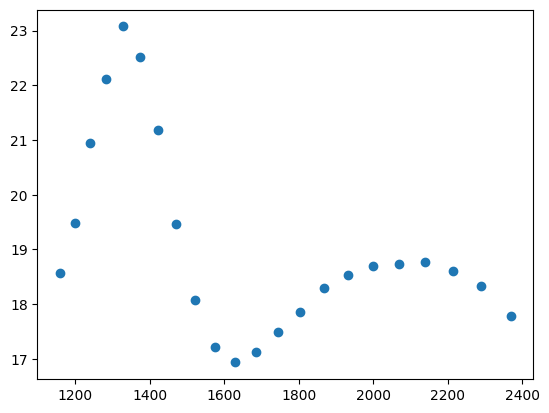

In [7]:
from pyPolCal.fitting import calc_s_res_global, update_p0
import matplotlib.pyplot as plt

# Update p0 with results
update_p0(p0_dict, result_min.x)

# Calculate s_rel
s_rel = calc_s_res_global(csvdir, system_dict, p0_dict, number_of_fitted_params=4)

# Plot
plt.scatter(wavelength_bins, s_rel)

I'm going to save this to a .txt to use for calculating $s_p$ and $s_{\chi}$ later on.

In [12]:

with open('s_rel.txt','w') as f:
    for sr in s_rel:
        f.write(f"{sr}\n")

This is the end for internal calibrations! If you have unpolarized internal calibration data you can follow the exact same procedure for both wavelength and global fitting, but get rid of the calibration polarizer in your system dictionary and fit for diattenuations.